In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pysse import ElectricFieldPulse, SSE

In [2]:
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [3]:
intensity = 1E4  # Intensity in W/cm^2
fwhm = 9.4  # FWHM in as
central_frequency = 250  # Pulse oscillation frequency in eV
dt = 5E-3
time_span = 8 # Time in a.u.

electric_field_pulse = ElectricFieldPulse(intensity=intensity, dt=dt, pulse_type='gaussian', fwhm=fwhm, omega_sin=central_frequency, time_span=time_span)

electric_field = {"time": electric_field_pulse.time, "pulse_x": electric_field_pulse.pulse, "pulse_y": np.zeros_like(electric_field_pulse.pulse), "pulse_z": np.zeros_like(electric_field_pulse.pulse)}

In [4]:
print(electric_field_pulse)

Electric Field Pulse:
  Intensity: 10000.0 W/cm^2
  FWHM: 9.4 as
  Central frequency: 9.18732590017419 a.u.
  E_max: 5.337605126836238e-07 a.u.
  Sigma: 0.1650270092543608 a.u.
  Time step (dt): 0.005 a.u.
  Number of steps: 1600
  Pulse type: gaussian
  Time at maximum: 1.0 a.u.
  Energy window: None a.u.
  Pulse width: None a.u.



In [5]:
propagation_method = "Heun"

Text(0.5, 1.0, 'FFT of Sinusoidal Gaussian Pulse')

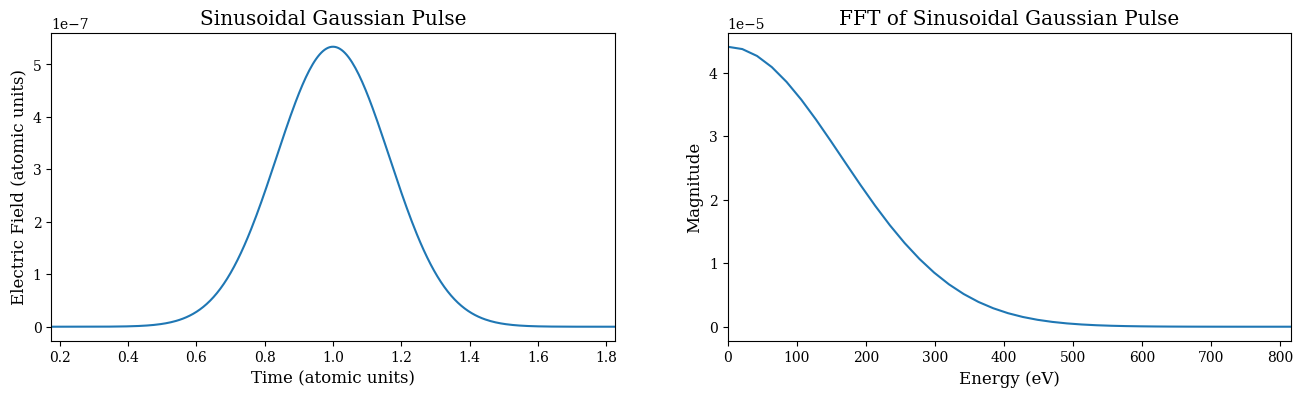

In [6]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
plt.plot(electric_field_pulse.time, electric_field_pulse.pulse, label='Carbon')
plt.xlabel('Time (atomic units)')
plt.ylabel('Electric Field (atomic units)')
plt.xlim(electric_field_pulse.time_limits)
plt.title('Sinusoidal Gaussian Pulse')

plt.subplot(1,2,2)
plt.plot(electric_field_pulse.freq, electric_field_pulse.magnitude)
plt.xlim(electric_field_pulse.freq_limits)
plt.xlabel('Energy (eV)')
plt.ylabel('Magnitude')
plt.title('FFT of Sinusoidal Gaussian Pulse')

In [7]:
gamma = np.array([
    [0,1,2]
]) # [final state, initial state, gamma]

In [8]:
initial_conditions = np.array([
    [1,1.0]
])

In [9]:
n_paths = 30
n_jobs = 10
random_seed = 10 #Candidates: 10, 14, 16, 24, 2008

In [10]:
sse = SSE("../data_minimal/dummy_data/", electric_field, gamma, initial_conditions, n_paths, propagation_method, n_jobs, random_seed)

In [11]:
p_0_0 = 0
p_1_0 = 1
p_0_th = 1 - p_1_0*np.exp(-sse.gamma[0,2]*sse.time)
p_1_th = p_1_0*np.exp(-sse.gamma[0,2]*sse.time)

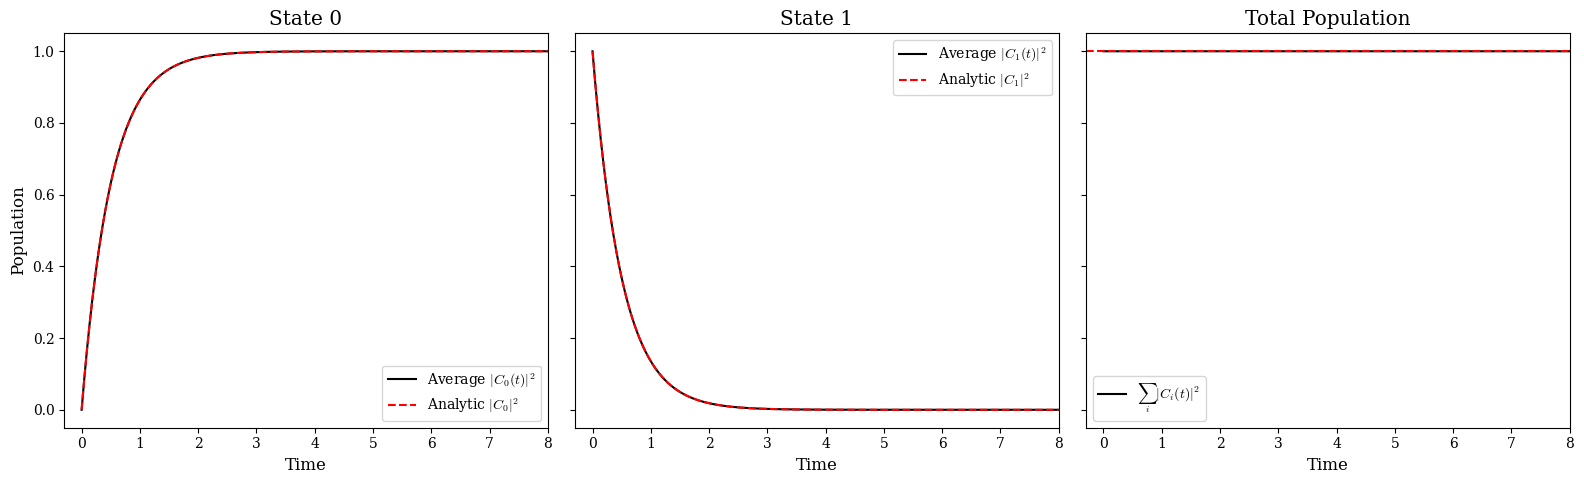

In [12]:
total_population = sse.population_average[:,0] + sse.population_average[:,1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Left subplot: |C_average[:,1]|^2 vs Analytic
axes[0].plot(sse.time, sse.population_average[:,0], label=r'Average $|C_0(t)|^2$', color='black')
axes[0].plot(sse.time, p_0_th, label=r'Analytic $|C_0|^2$', color='red', linestyle='--')
axes[0].set_title('State 0')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Population')
axes[0].set_xlim(-0.3, time_span)
axes[0].legend()

# Middle subplot: |C_average[:,0]|^2 vs Analytic
axes[1].plot(sse.time, sse.population_average[:,1], label=r'Average $|C_1(t)|^2$', color='black')
axes[1].plot(sse.time, p_1_th, label=r'Analytic $|C_1|^2$', color='red', linestyle='--')
axes[1].set_title('State 1')
axes[1].set_xlabel('Time')
#axes[1].set_ylabel('Population')
axes[1].set_xlim(-0.3, time_span)
axes[1].legend()

# Right subplot: total population
axes[2].plot(sse.time, total_population, label=r'$\sum_i |C_i(t)|^2$', color='black')
axes[2].axhline(1, color='red', linestyle='--')
axes[2].set_title('Total Population')
axes[2].set_xlabel('Time')
#axes[2].set_ylabel('Population')
axes[2].set_xlim(-0.3, time_span)
axes[2].legend()

plt.tight_layout()
plt.show()